## Part 1.1 -> Installation
Install the required libraries.

In [1]:
%pip install opencv-python matplotlib pandas numpy -q

Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.13 requires protobuf<5,>=4.25.3, but you have protobuf 5.29.6 which is incompatible.
numba 0.66.0 requires numpy<2.5,>=1.22, but you have numpy 2.5.2 which is incompatible.
streamlit 1.48.0 requires pillow<12,>=7.1.0, but you have pillow 12.3.0 which is incompatible.
unstructured-inference 1.6.13 requires onnxruntime>=1.25.0, but you have onnxruntime 1.20.1 which is incompatible.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Part 1.2 -> Import & Validate
Import libraries and run a quick validation check.

OpenCV version: 4.13.0
NumPy version: 2.5.2
Pandas version: 2.3.3


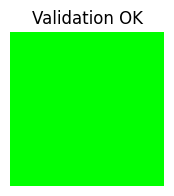

cv2 and matplotlib are working correctly.


In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

# Quick validation: create a tiny throwaway array and plot it
_test = np.zeros((10, 10, 3), dtype=np.uint8)
_test[:, :] = (0, 255, 0)
plt.figure(figsize=(2, 2))
plt.imshow(_test)
plt.title("Validation OK")
plt.axis('off')
plt.show()
print("cv2 and matplotlib are working correctly.")


### Generate a sample working image
Since no image file was provided, this cell generates `sample.jpg` and `document.jpg`
(a high-contrast grayscale-style image for the thresholding task) so every later task
has something real to load from disk.

In [3]:
# Create a colorful synthetic "photo" to stand in for a real image (sample.jpg)
h, w = 600, 800
sample = np.zeros((h, w, 3), dtype=np.uint8)
for y in range(h):
    sample[y, :, 0] = int(255 * (y / h))                 # Blue channel gradient
    sample[y, :, 1] = 120                                  # Green constant
    sample[y, :, 2] = int(255 * (1 - y / h))               # Red channel gradient
cv2.circle(sample, (w // 2, h // 2), 120, (0, 0, 255), -1)
cv2.rectangle(sample, (50, 50), (250, 200), (255, 0, 0), -1)
cv2.imwrite('sample.jpg', sample)

# Create a second image for masking task (image_b.jpg)
image_b = np.zeros((h, w, 3), dtype=np.uint8)
cv2.rectangle(image_b, (0, 0), (w, h), (40, 40, 40), -1)
for i in range(0, w, 40):
    cv2.line(image_b, (i, 0), (i, h), (200, 200, 0), 3)
cv2.imwrite('image_b.jpg', image_b)

# Create a high-contrast "document" image for thresholding (document.jpg)
doc = np.full((500, 500), 255, dtype=np.uint8)
cv2.putText(doc, 'SAMPLE DOCUMENT', (30, 100), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0,), 3)
cv2.putText(doc, 'Line of text 1234567890', (30, 200), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,), 2)
noise = (np.random.randn(500, 500) * 15).astype(np.int16)
doc = np.clip(doc.astype(np.int16) + noise, 0, 255).astype(np.uint8)
cv2.imwrite('document.jpg', doc)

print("Created sample.jpg, image_b.jpg, document.jpg")


Created sample.jpg, image_b.jpg, document.jpg


## Task 1 -> Object-Oriented Grocery Manager

In [5]:
class GroceryManager:
    """Manages a grocery list with add/remove/view/total operations."""

    def __init__(self):
        self.items = {}  # item_name -> {'quantity': int, 'price': float}

    def add_item(self, item, quantity, price):
        if quantity <= 0 or price < 0:
            print(f"Error: Invalid quantity/price for '{item}'.")
            return
        if item in self.items:
            self.items[item]['quantity'] += quantity
        else:
            self.items[item] = {'quantity': quantity, 'price': price}
        print(f"Added: {quantity} x {item} @ ${price:.2f}")

    def remove_item(self, item):
        if item not in self.items:
            print(f"Error: '{item}' is not in the grocery list.")
            return
        del self.items[item]
        print(f"Removed: {item}")

    def view_list(self):
        if not self.items:
            print("Grocery list is empty.")
            return
        print(f"{'Item':<15}{'Qty':<8}{'Price':<10}{'Subtotal':<10}")
        for item, info in self.items.items():
            subtotal = info['quantity'] * info['price']
            print(f"{item:<15}{info['quantity']:<8}{info['price']:<10.2f}{subtotal:<10.2f}")

    def calculate_total(self):
        return sum(info['quantity'] * info['price'] for info in self.items.values())


# Demo
gm = GroceryManager()
gm.add_item("Milk", 2, 1.50)
gm.add_item("Bread", 1, 2.75)
gm.add_item("Eggs", 12, 0.25)
gm.view_list()
print("Total: $%.2f" % gm.calculate_total())

gm.remove_item("Bread")
gm.remove_item("Butter")  # triggers error handling
gm.view_list()


Added: 2 x Milk @ $1.50
Added: 1 x Bread @ $2.75
Added: 12 x Eggs @ $0.25
Item           Qty     Price     Subtotal  
Milk           2       1.50      3.00      
Bread          1       2.75      2.75      
Eggs           12      0.25      3.00      
Total: $8.75
Removed: Bread
Error: 'Butter' is not in the grocery list.
Item           Qty     Price     Subtotal  
Milk           2       1.50      3.00      
Eggs           12      0.25      3.00      


## Task 2 -> Advanced Student Record System

In [6]:
students = {
    "S001": {"Name": "Alice",   "Major": "Computer Science", "Grades": [90, 85, 92]},
    "S002": {"Name": "Bob",     "Major": "Mathematics",       "Grades": [78, 82, 75]},
    "S003": {"Name": "Charlie", "Major": "Computer Science", "Grades": [95, 91, 89]},
    "S004": {"Name": "Diana",   "Major": "Physics",           "Grades": [88, 84, 90]},
}


def top_student(records):
    """Returns the name of the student with the highest average grade."""
    best_name, best_avg = None, -1
    for info in records.values():
        avg = sum(info["Grades"]) / len(info["Grades"])
        if avg > best_avg:
            best_avg, best_name = avg, info["Name"]
    return best_name, best_avg


def search_by_major(records, major):
    """Prints all students enrolled in the given major."""
    found = [info["Name"] for info in records.values() if info["Major"].lower() == major.lower()]
    if found:
        print(f"Students in {major}: {', '.join(found)}")
    else:
        print(f"No students found in major: {major}")


name, avg = top_student(students)
print(f"Top student: {name} (avg = {avg:.2f})")

search_by_major(students, "Computer Science")
search_by_major(students, "Biology")


Top student: Charlie (avg = 91.67)
Students in Computer Science: Alice, Charlie
No students found in major: Biology


## Task 3 -> Safe Image Loading & RGB Visualization

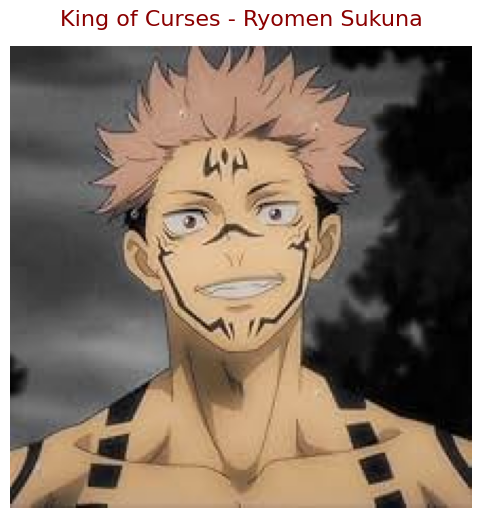

In [7]:
image_path = 'Sukuna.jpg'
image = cv2.imread(image_path)
if image is None:
    print(f"'{image_path}' not found, falling back to sample.jpg")
    image_path = 'sample.jpg'
    image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.axis('off')
    plt.imshow(image_rgb)
    plt.title('King of Curses - Ryomen Sukuna', fontsize=16, color='darkred', pad=15)
    plt.show()


## Task 4 -> Interactive Geometry & Blank Canvas

Canvas center coordinates: (400, 400)


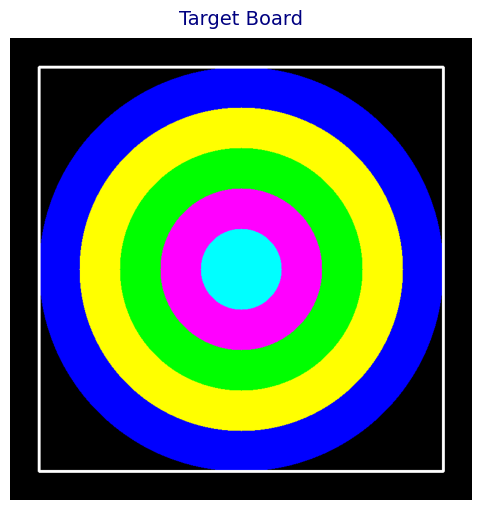

In [8]:
canvas = np.zeros((800, 800, 3), dtype=np.uint8)

colors = [(255, 0, 0), (0, 255, 255), (0, 255, 0), (255, 0, 255), (255, 255, 0)]
center = (400, 400)
radii = [350, 280, 210, 140, 70]

for radius, color in zip(radii, colors):
    cv2.circle(canvas, center, radius, color, thickness=-1)

# Bounding box around outermost circle
top_left = (center[0] - radii[0], center[1] - radii[0])
bottom_right = (center[0] + radii[0], center[1] + radii[0])
cv2.rectangle(canvas, top_left, bottom_right, (255, 255, 255), thickness=3)

print(f"Canvas center coordinates: {center}")

canvas_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.axis('off')
plt.imshow(canvas_rgb)
plt.title('Target Board', fontsize=14, color='navy', pad=10)
plt.show()


## Task 5 -> Advanced Blurring & NumPy ROI Extraction

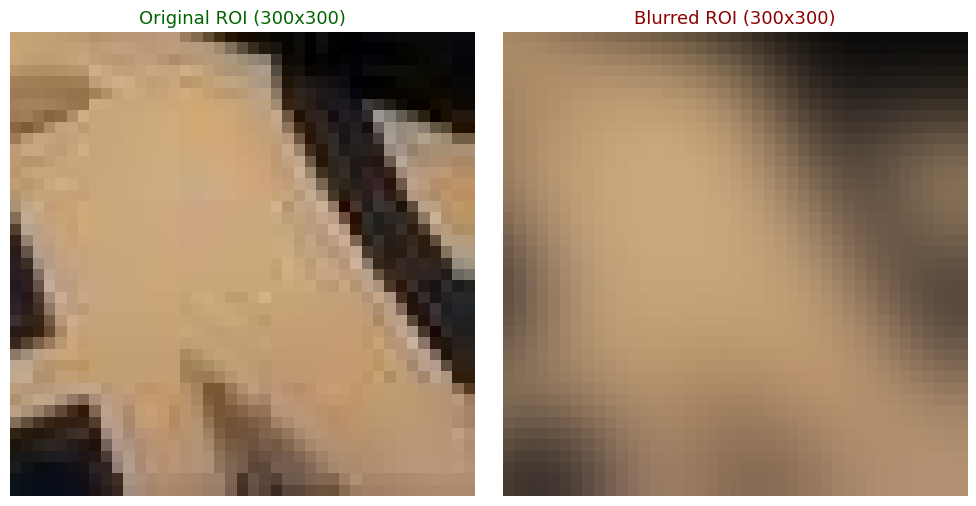

In [9]:
image_path = 'Sukuna.jpg'
image = cv2.imread(image_path)
if image is None:
    print(f"'{image_path}' not found, falling back to sample.jpg")
    image_path = 'sample.jpg'
    image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    blurred_rgb = cv2.cvtColor(cv2.GaussianBlur(image, (25, 25), 0), cv2.COLOR_BGR2RGB)

    h, w, _ = image_rgb.shape
    cy, cx = h // 2, w // 2
    half = 150  # half of 300

    roi_original = image_rgb[cy - half:cy + half, cx - half:cx + half]
    roi_blurred = blurred_rgb[cy - half:cy + half, cx - half:cx + half]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(roi_original)
    axes[0].set_title('Original ROI (300x300)', fontsize=13, color='darkgreen')
    axes[0].axis('off')

    axes[1].imshow(roi_blurred)
    axes[1].set_title('Blurred ROI (300x300)', fontsize=13, color='darkred')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()


## Task 6 -> Alpha Blending & Typography

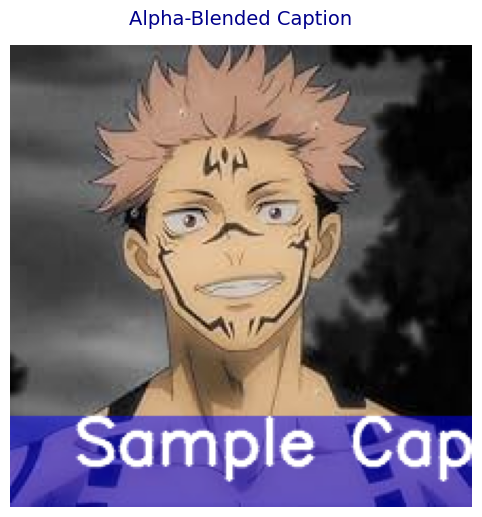

In [10]:
image_path = 'Sukuna.jpg'
image = cv2.imread(image_path)
if image is None:
    print(f"'{image_path}' not found, falling back to sample.jpg")
    image_path = 'sample.jpg'
    image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")
else:
    h, w, _ = image.shape
    overlay = image.copy()
    band_height = int(h * 0.20)
    cv2.rectangle(overlay, (0, h - band_height), (w, h), (255, 0, 0), thickness=-1)

    blended = cv2.addWeighted(overlay, 0.5, image, 0.5, 0)

    cv2.putText(blended, 'Sample Caption Title', (30, h - band_height // 2),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2, cv2.LINE_AA)

    blended_rgb = cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.axis('off')
    plt.imshow(blended_rgb)
    plt.title('Alpha-Blended Caption', fontsize=14, color='darkblue', pad=15)
    plt.show()


## Task 7 -> Matrix-Based Rotation & Adaptive Thresholding

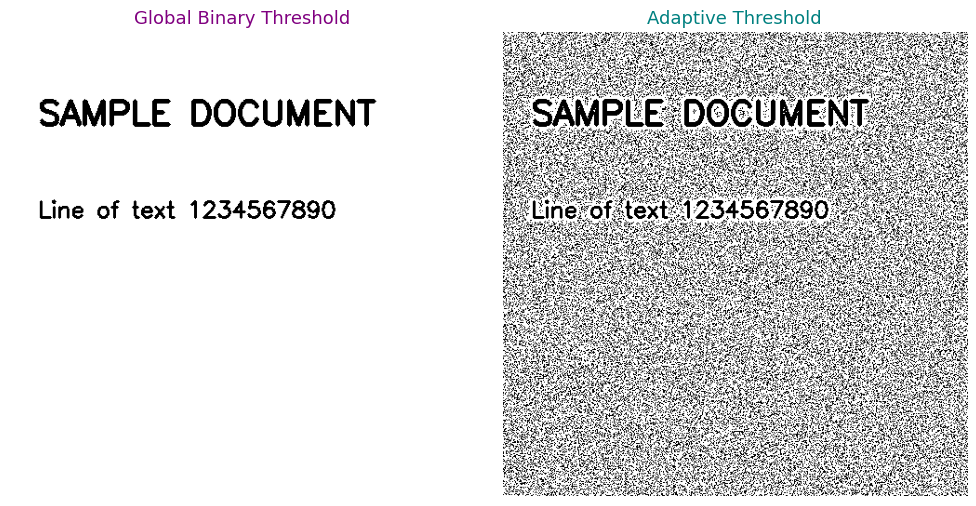

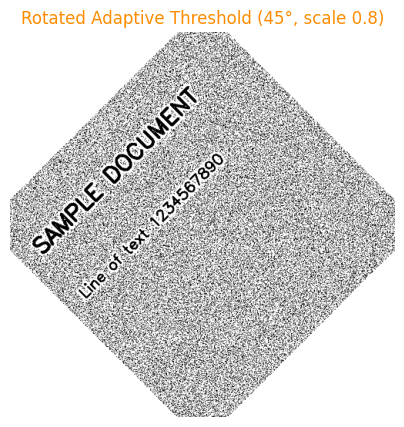

In [11]:
doc_path = 'document.jpg'
doc_image = cv2.imread(doc_path, cv2.IMREAD_GRAYSCALE)

if doc_image is None:
    print("Error: Image not found.")
else:
    _, global_thresh = cv2.threshold(doc_image, 127, 255, cv2.THRESH_BINARY)
    adaptive_thresh = cv2.adaptiveThreshold(
        doc_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(global_thresh, cmap='gray')
    axes[0].set_title('Global Binary Threshold', fontsize=13, color='purple')
    axes[0].axis('off')

    axes[1].imshow(adaptive_thresh, cmap='gray')
    axes[1].set_title('Adaptive Threshold', fontsize=13, color='teal')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    # Rotate the adaptive threshold output by 45 degrees, scale 0.8
    (h, w) = adaptive_thresh.shape[:2]
    center = (w // 2, h // 2)
    rot_matrix = cv2.getRotationMatrix2D(center, 45, 0.8)
    rotated = cv2.warpAffine(adaptive_thresh, rot_matrix, (w, h), borderValue=255)

    plt.figure(figsize=(5, 5))
    plt.imshow(rotated, cmap='gray')
    plt.title('Rotated Adaptive Threshold (45°, scale 0.8)', fontsize=12, color='darkorange')
    plt.axis('off')
    plt.show()


## Task 8 -> Masking with Bitwise Logic

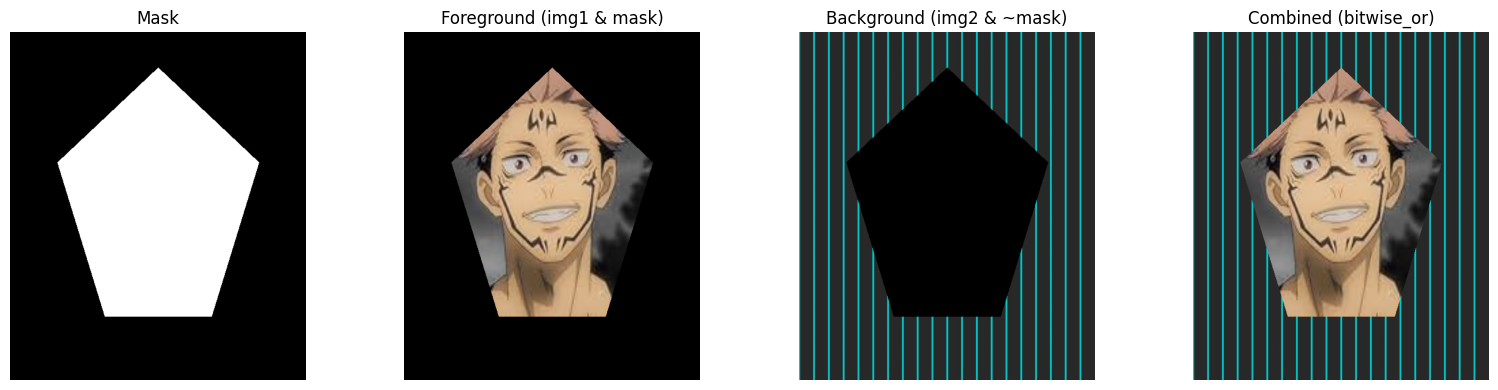

In [12]:
img1 = cv2.imread('Sukuna.jpg')
if img1 is None:
    print("'Sukuna.jpg' not found, falling back to sample.jpg")
    img1 = cv2.imread('sample.jpg')
img2 = cv2.imread('image_b.jpg')

if img1 is None or img2 is None:
    print("Error: One or both images not found.")
else:
    target_size = (500, 588)  # width, height
    img1 = cv2.resize(img1, target_size)
    img2 = cv2.resize(img2, target_size)

    # Binary mask: black canvas with white polygon in the center
    mask = np.zeros(target_size[::-1], dtype=np.uint8)  # (height, width)
    poly_pts = np.array([
        [250, 60], [420, 220], [340, 480],
        [160, 480], [80, 220]
    ], dtype=np.int32)
    cv2.fillPoly(mask, [poly_pts], 255)

    # Cut the polygon shape out of image 1
    fg = cv2.bitwise_and(img1, img1, mask=mask)

    # Invert mask, cut background out of image 2
    inverse_mask = cv2.bitwise_not(mask)
    bg = cv2.bitwise_and(img2, img2, mask=inverse_mask)

    # Combine
    combined = cv2.bitwise_or(fg, bg)
    combined_rgb = cv2.cvtColor(combined, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(mask, cmap='gray'); axes[0].set_title('Mask'); axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(fg, cv2.COLOR_BGR2RGB)); axes[1].set_title('Foreground (img1 & mask)'); axes[1].axis('off')
    axes[2].imshow(cv2.cvtColor(bg, cv2.COLOR_BGR2RGB)); axes[2].set_title('Background (img2 & ~mask)'); axes[2].axis('off')
    axes[3].imshow(combined_rgb); axes[3].set_title('Combined (bitwise_or)'); axes[3].axis('off')
    plt.tight_layout()
    plt.show()


## Task 9 -> Statistical Image Profiling with Pandas

In [13]:
image_path = 'Sukuna.jpg'
image = cv2.imread(image_path)
if image is None:
    print(f"'{image_path}' not found, falling back to sample.jpg")
    image_path = 'sample.jpg'
    image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    red_channel = image_rgb[:, :, 0].flatten()
    green_channel = image_rgb[:, :, 1].flatten()
    blue_channel = image_rgb[:, :, 2].flatten()

    df = pd.DataFrame({
        'Red': red_channel,
        'Green': green_channel,
        'Blue': blue_channel
    })

    print(df.describe())


                Red         Green          Blue
count  47524.000000  47524.000000  47524.000000
mean     118.677047    101.835431     85.912718
std       73.475498     59.336812     46.724888
min        0.000000      0.000000      0.000000
25%       63.000000     61.000000     56.000000
50%      107.000000    100.000000     94.000000
75%      194.000000    157.000000    124.000000
max      255.000000    234.000000    231.000000
